In [206]:
import pandas as pd
import matplotlib.pyplot as plt

In [207]:
df=pd.read_csv("mushroom.csv")

In [208]:
df.head()

,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [209]:
df.tail()

,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [210]:
df.shape

(8124, 23)

In [211]:
df.isna().sum()

class                          0
cap_shape                      0
cap_surface                    0
cap_color                      0
bruises                        0
odor                           0
gill_attachment                0
gill_spacing                   0
gill_size                      0
gill_color                     0
stalk_shape                    0
stalk_root                  2480
stalk_surface_above_ring       0
stalk_surface_below_ring       0
stalk_color_above_ring         0
stalk_color_below_ring         0
veil_type                      0
veil_color                     0
ring_number                    0
ring_type                      0
spore_print_color              0
population                     0
habitat                        0
dtype: int64

In [212]:
df["stalk_root"]=df["stalk_root"].fillna(df["stalk_root"].mode()[0])

In [213]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8119    False
8120    False
8121    False
8122    False
8123    False
Length: 8124, dtype: bool

In [214]:
df.drop_duplicates(inplace=True)

In [215]:
clas=df["class"].value_counts()
clas

class
e    4208
p    3916
Name: count, dtype: int64

<BarContainer object of 2 artists>

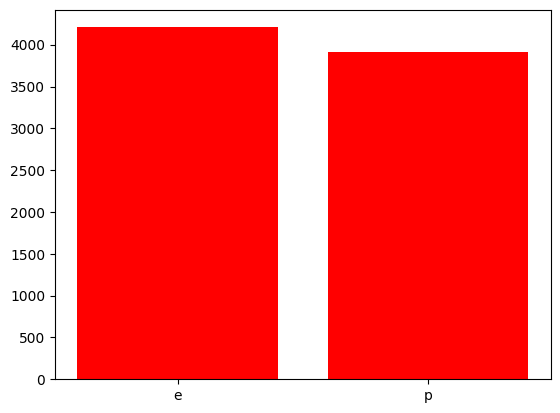

In [216]:
plt.bar(clas.index,clas.values,color="r")

In [217]:
df.dtypes

class                       str
cap_shape                   str
cap_surface                 str
cap_color                   str
bruises                     str
odor                        str
gill_attachment             str
gill_spacing                str
gill_size                   str
gill_color                  str
stalk_shape                 str
stalk_root                  str
stalk_surface_above_ring    str
stalk_surface_below_ring    str
stalk_color_above_ring      str
stalk_color_below_ring      str
veil_type                   str
veil_color                  str
ring_number                 str
ring_type                   str
spore_print_color           str
population                  str
habitat                     str
dtype: object

In [218]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
column=["class","cap_shape","cap_surface","cap_color","bruises","odor","gill_attachment","gill_spacing",
        "gill_size","gill_color","stalk_shape","stalk_root","stalk_surface_above_ring",
        "stalk_surface_below_ring","stalk_color_above_ring","stalk_color_below_ring","veil_type",
        "veil_color","ring_number","ring_type","spore_print_color","population","habitat"
        
        ]

for col in column:
    df[col]=le.fit_transform(df[col])

In [219]:
from sklearn.model_selection import train_test_split

In [220]:
x=df.drop(columns="class")
y=df["class"]

In [221]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.30,random_state=1)

In [222]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix,accuracy_score


knn=KNeighborsClassifier(n_neighbors=5)
svm=SVC()
nb=MultinomialNB()

lst=[knn,svm,nb]


In [223]:
for i in lst:
    print("model selection_____________",i)
    print(i.fit(x_train,y_train))
    y_pred=i.predict(x_test)

    print("confusion matrix_____________",i)
    print(confusion_matrix(y_test,y_pred))

    print("accuracy score_____________",i)
    print(accuracy_score(y_test,y_pred))

model selection_____________ KNeighborsClassifier()
KNeighborsClassifier()
confusion matrix_____________ KNeighborsClassifier()
[[1236    0]
 [   6 1196]]
accuracy score_____________ KNeighborsClassifier()
0.9975389663658737
model selection_____________ SVC()
SVC()
confusion matrix_____________ SVC()
[[1235    1]
 [  30 1172]]
accuracy score_____________ SVC()
0.9872846595570139
model selection_____________ MultinomialNB()
MultinomialNB()
confusion matrix_____________ MultinomialNB()
[[1175   61]
 [ 351  851]]
accuracy score_____________ MultinomialNB()
0.8310090237899918
